In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import planetary_computer as pc
from pystac_client import Client
import pandas as pd
import numpy as np
import geopy.distance as distance
from datetime import timedelta
from time import time
import matplotlib.pyplot as plt

import rioxarray
from IPython.display import Image
from PIL import Image as PILImage

from pyproj import Transformer


In [3]:

def get_bounding_box(latitude, longitude, meter_buffer=50000):
    """
    Given a latitude, longitude, and buffer in meters, returns a bounding
    box around the point with the buffer on the left, right, top, and bottom.

    Returns a list of [minx, miny, maxx, maxy]
    """
    distance_search = distance.distance(meters=meter_buffer)

    # calculate the lat/long bounds based on ground distance
    # bearings are cardinal directions to move (south, west, north, and east)
    min_lat = distance_search.destination((latitude, longitude), bearing=180)[0]
    min_long = distance_search.destination((latitude, longitude), bearing=270)[1]
    max_lat = distance_search.destination((latitude, longitude), bearing=0)[0]
    max_long = distance_search.destination((latitude, longitude), bearing=90)[1]

    return [min_long, min_lat, max_long, max_lat]



In [4]:

def get_date_range(date, time_buffer_days=15):
    """Get a date range to search for in the planetary computer based
    on a sample's date. The time range will include the sample date
    and time_buffer_days days prior

    Returns a string"""
    datetime_format = "%Y-%m-%d"
    range_start = pd.to_datetime(date) - timedelta(days=time_buffer_days)
    range_end = pd.to_datetime(date) + timedelta(days=time_buffer_days)
    date_range = f"{range_start.strftime(datetime_format)}/{range_end.strftime(datetime_format)}"

    return date_range



In [5]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace
)


In [6]:
df = pd.read_excel(r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\tick tick bloom data\junk4.xlsx")
high_sev = df[(df.severity > 3)&(df.date >= "2017-01-01")]

In [7]:
high_sev.cluster_size.value_counts().sort_index(ascending=False)

cluster_size
37       1
26      13
22       1
21       4
20       4
18       8
16       6
15       1
14       1
13       6
12       2
11       3
10      16
9        2
8        5
7       15
6       34
5       37
4      119
3      100
2      437
1     2580
Name: count, dtype: int64

In [8]:
high_sev[high_sev.cluster_size == 26]

,uid,data_provider,region,lat,lon,date,time,year,month,day,abun,severity,distance_to_water_m,cyfi class,case,case_str,cluster_size
2277,cedy,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-09-04,0:01:00,2019,9,4,1626.975,4,0.0,High,1858,1858,26
2278,cnsz,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-10-07,0:01:00,2019,10,7,1197.000,4,0.0,High,1858,"1858 , 1858 , 1858",26
2285,difw,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-08-12,0:01:00,2019,8,12,1020.600,4,0.0,High,1858,"1858 , 1858",26
2292,fjjk,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-09-04,0:01:00,2019,9,4,1409.625,4,0.0,High,1858,1858,26
2302,gkdu,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-07-15,0:01:00,2019,7,15,1045.800,4,0.0,High,1858,"1858 , 1858",26
2303,gmhy,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-09-23,0:01:00,2019,9,23,1339.380,4,0.0,High,1858,"1858 , 1858 , 1858",26
2322,kict,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-07-29,0:01:00,2019,7,29,1030.680,4,0.0,High,1858,"1858 , 1858 , 1858 , 1858",26
2335,myfe,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-08-19,0:01:00,2019,8,19,1292.130,4,0.0,High,1858,"1858 , 1858 , 1858",26
2344,oots,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-08-19,0:01:00,2019,8,19,4528.125,4,0.0,High,1858,"1858 , 1858 , 1858",26
2380,swim,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-07-15,0:01:00,2019,7,15,1251.810,4,0.0,High,1858,"1858 , 1858",26


In [9]:
d1 = high_sev[high_sev.case == 1858]
d1

,uid,data_provider,region,lat,lon,date,time,year,month,day,abun,severity,distance_to_water_m,cyfi class,case,case_str,cluster_size
2277,cedy,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-09-04,0:01:00,2019,9,4,1626.975,4,0.0,High,1858,1858,26
2278,cnsz,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-10-07,0:01:00,2019,10,7,1197.000,4,0.0,High,1858,"1858 , 1858 , 1858",26
2285,difw,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-08-12,0:01:00,2019,8,12,1020.600,4,0.0,High,1858,"1858 , 1858",26
2292,fjjk,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-09-04,0:01:00,2019,9,4,1409.625,4,0.0,High,1858,1858,26
2302,gkdu,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-07-15,0:01:00,2019,7,15,1045.800,4,0.0,High,1858,"1858 , 1858",26
2303,gmhy,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-09-23,0:01:00,2019,9,23,1339.380,4,0.0,High,1858,"1858 , 1858 , 1858",26
2322,kict,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-07-29,0:01:00,2019,7,29,1030.680,4,0.0,High,1858,"1858 , 1858 , 1858 , 1858",26
2335,myfe,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-08-19,0:01:00,2019,8,19,1292.130,4,0.0,High,1858,"1858 , 1858 , 1858",26
2344,oots,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-08-19,0:01:00,2019,8,19,4528.125,4,0.0,High,1858,"1858 , 1858 , 1858",26
2380,swim,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-07-15,0:01:00,2019,7,15,1251.810,4,0.0,High,1858,"1858 , 1858",26


In [10]:
d1.date.value_counts().sort_index(ascending=False)

date
2019-10-07    1
2019-09-23    1
2019-09-04    2
2019-08-26    1
2019-08-19    2
2019-08-12    1
2019-08-05    1
2019-07-29    1
2019-07-15    2
2019-06-24    1
Name: count, dtype: int64

In [11]:
test_dates = d1[d1.date == "2019-08-19"]
print(test_dates.shape)
p_lon = np.mean([min(test_dates.lon),max(test_dates.lon)])
p_lat = np.mean([min(test_dates.lat),max(test_dates.lat)])
print(p_lon, p_lat, set(test_dates.date))


(2, 17)
-96.8836665 39.0783175 {Timestamp('2019-08-19 00:00:00')}


In [12]:

bbox = get_bounding_box(p_lat, p_lon, meter_buffer=3000)
print(bbox)


[-96.91833622427428, 39.05129454297629, -96.84899677572572, 39.10534033143383]


In [13]:

date_range = get_date_range(test_dates.date.iloc[0])
date_range


'2019-08-04/2019-09-03'

In [14]:

search = catalog.search(
    collections=["sentinel-2-l2a"], bbox=bbox, datetime=date_range
)


In [15]:

t1 = time()
items = [item for item in search.get_all_items()]
t2 = time()
len(items)



C:\Users\KostasPikounis\anaconda3\envs\AMFITRITE\lib\site-packages\pystac_client\item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


6

In [16]:

item_details = pd.DataFrame(
    [
        {
            "datetime": item.datetime.strftime("%Y-%m-%d"),
            "platform": item.properties["platform"],
            "min_long": item.bbox[0],
            "max_long": item.bbox[2],
            "min_lat": item.bbox[1],
            "max_lat": item.bbox[3],
            "bbox": item.bbox,
            "item_obj": item,
        }
        for item in items
    ]
)

# check which rows actually contain the sample location
item_details["contains_sample_point"] = (
    (item_details.min_lat < p_lat)
    & (item_details.max_lat > p_lat)
    & (item_details.min_long < p_lon)
    & (item_details.max_long > p_lon)
)

print(
    f"Filtering from {len(item_details)} returned to {item_details.contains_sample_point.sum()} items that contain the sample location"
)

item_details = item_details[item_details["contains_sample_point"]]
item_details[["datetime", "platform", "contains_sample_point", "bbox"]].sort_values(
    by="datetime"
)

item_details["per_clouds"] = -1


Filtering from 6 returned to 6 items that contain the sample location


In [17]:
for it, row in item_details.iterrows():
    ar = rioxarray.open_rasterio(pc.sign(row.item_obj.assets["SCL"].href)).to_numpy()
    cloud_per = round(100*sum(ar >= 7).sum()/(ar.shape[0]*ar.shape[1]*ar.shape[2]),2)
    item_details.at[it, "per_clouds"] = cloud_per

item_details['date_difference'] = (pd.to_datetime(item_details['datetime']) - test_dates.date.iloc[0]).dt.days
item_details

C:\Users\KostasPikounis\AppData\Local\Temp\ipykernel_39208\2006908942.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.52' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  item_details.at[it, "per_clouds"] = cloud_per


,datetime,platform,min_long,max_long,min_lat,max_lat,bbox,item_obj,contains_sample_point,per_clouds,date_difference
0,2019-09-02,Sentinel-2B,-97.849128,-96.552115,38.735936,39.743725,"[-97.84912778038333, 38.73593643111066, -96.55...",<Item id=S2B_MSIL2A_20190902T170849_R112_T14SP...,True,0.52,14
1,2019-08-28,Sentinel-2A,-97.849120,-96.552124,38.735936,39.743773,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2A_MSIL2A_20190828T170851_R112_T14SP...,True,0.78,9
2,2019-08-23,Sentinel-2B,-97.849120,-96.552124,38.735936,39.743766,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2B_MSIL2A_20190823T170859_R112_T14SP...,True,80.84,4
3,2019-08-18,Sentinel-2A,-97.849120,-96.552124,38.735936,39.743795,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2A_MSIL2A_20190818T170851_R112_T14SP...,True,0.53,-1
4,2019-08-13,Sentinel-2B,-97.849120,-96.552124,38.735936,39.743782,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2B_MSIL2A_20190813T170859_R112_T14SP...,True,16.62,-6
5,2019-08-08,Sentinel-2A,-97.849120,-96.552124,38.735936,39.743805,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2A_MSIL2A_20190808T170901_R112_T14SP...,True,88.11,-11


In [18]:
### low cloud percnetage and close to date

In [19]:


item = item_details.at[3, "item_obj"]

item

<Item id=S2A_MSIL2A_20190818T170851_R112_T14SPJ_20201005T015156>

In [20]:
for asset_key, asset in item.assets.items():
    print(f"{asset_key:<25} - {asset.title}")

AOT                       - Aerosol optical thickness (AOT)
B01                       - Band 1 - Coastal aerosol - 60m
B02                       - Band 2 - Blue - 10m
B03                       - Band 3 - Green - 10m
B04                       - Band 4 - Red - 10m
B05                       - Band 5 - Vegetation red edge 1 - 20m
B06                       - Band 6 - Vegetation red edge 2 - 20m
B07                       - Band 7 - Vegetation red edge 3 - 20m
B08                       - Band 8 - NIR - 10m
B09                       - Band 9 - Water vapor - 60m
B11                       - Band 11 - SWIR (1.6) - 20m
B12                       - Band 12 - SWIR (2.2) - 20m
B8A                       - Band 8A - Vegetation red edge 4 - 20m
SCL                       - Scene classfication map (SCL)
WVP                       - Water vapour (WVP)
visual                    - True color image
preview                   - Thumbnail
safe-manifest             - SAFE manifest
granule-metadata          - Granul

In [21]:
# see the whole image
img = Image(url=item.assets["rendered_preview"].href, width=10000)
Image(url=item.assets["rendered_preview"].href, width=10000)

In [22]:
visual_href = pc.sign(item.assets["visual"].href)

In [23]:
ds = rioxarray.open_rasterio(visual_href)

bbox = get_bounding_box(p_lat, p_lon, meter_buffer=2000)

ds_clip = ds.rio.clip_box(
    minx=bbox[0], 
    miny=bbox[1], 
    maxx=bbox[2], 
    maxy=bbox[3], 
    crs="EPSG:4326" # This tells code that your bbox is in Lat/Lon
)

In [24]:
image_crs = ds_clip.rio.crs
transformer = Transformer.from_crs("EPSG:4326", image_crs, always_xy=True)

In [25]:
xx, yy = transformer.transform(test_dates.lon.values, test_dates.lat.values)

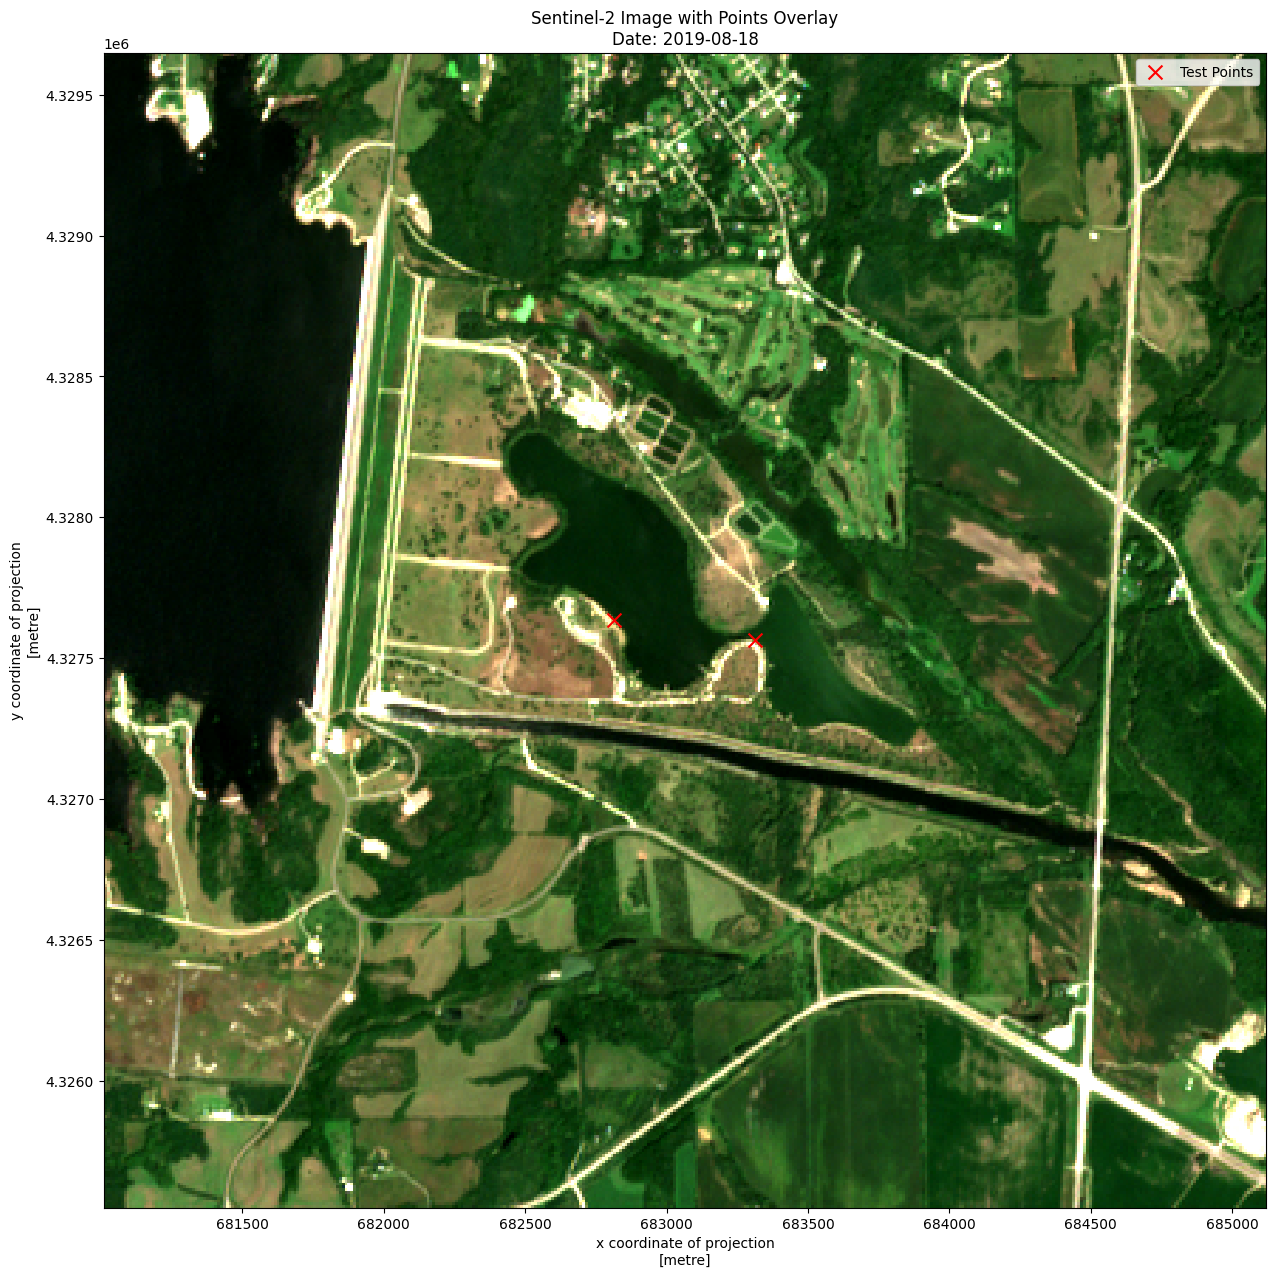

In [26]:
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the satellite image
# robust=True handles color scaling so the image isn't too dark or bright
ds_clip.plot.imshow(ax=ax, rgb="band", robust=True)

# Plot the points on top
ax.scatter(xx, yy, c='red', s=100, marker='x', label='Test Points')

ax.set_title(f"Sentinel-2 Image with Points Overlay\nDate: {item.datetime.date()}")
plt.legend()
plt.show()

In [27]:
import geopandas as gpd
from shapely.geometry import Point
from pyproj import CRS, Transformer
from pathlib import Path
import json
import warnings
import rasterio

In [28]:
def extract_and_save_tile(
    item,
    points_df,
    initial_pixel_size=100,
    save_data=False,
    output_path=None
):
    """
    Extracts, clips, visualizes individually, and optionally saves a square tile 
    around a set of reference points, including NDVI and NDCI.

    Args:
        item (pystac.Item): The selected Sentinel-2 STAC item.
        points_df (pd.DataFrame): DataFrame with 'lat' and 'lon' columns.
        initial_pixel_size (int): The initial square tile dimension (in pixels)
                                  at the 10m resolution (B04, B08, visual, etc.).
        save_data (bool): If True, saves the data to disk.
        output_path (str | Path, optional): Directory to save the output data.
    """
    # --- 1. Setup and Bounding Box Calculation (Same as before) ---
    print("--- Starting Tile Extraction and Processing ---")
    
    target_crs = CRS.from_string(item.properties["proj:code"])
    center_lat = points_df['lat'].mean()
    center_lon = points_df['lon'].mean()
    print(f"Center Point (Lat/Lon): ({center_lat:.4f}, {center_lon:.4f})")
    
    initial_side_meters = initial_pixel_size * 10
    
    points_gdf = gpd.GeoDataFrame(
        points_df, 
        geometry=gpd.points_from_xy(points_df.lon, points_df.lat), 
        crs=CRS.from_string("EPSG:4326")
    )
    points_gdf = points_gdf.to_crs(target_crs)
    minx_points, miny_points, maxx_points, maxy_points = points_gdf.total_bounds
    
    center_x = (minx_points + maxx_points) / 2
    center_y = (miny_points + maxy_points) / 2
    
    required_width_meters = maxx_points - minx_points
    required_height_meters = maxy_points - miny_points
    required_margin_meters = max(required_width_meters, required_height_meters) / 2
    
    final_margin_meters = max(initial_side_meters / 2, required_margin_meters)
    
    min_x_final = center_x - final_margin_meters
    max_x_final = center_x + final_margin_meters
    min_y_final = center_y - final_margin_meters
    max_y_final = center_y + final_margin_meters
    
    final_pixel_side = int((max_x_final - min_x_final) / 10)
    print(f"Final Tile Dimension (10m pixels): {final_pixel_side} x {final_pixel_side}")
    
    clip_bbox_utm = (min_x_final, min_y_final, max_x_final, max_y_final)
    transformer_latlon_to_utm = Transformer.from_crs(CRS.from_string("EPSG:4326"), target_crs, always_xy=True)
    
    # --- 2. Asset Clipping and Processing ---
    
    # List of bands to load and their native GSD
    band_gsd_map = {
        "B02": 10, "B03": 10, "B04": 10, "B08": 10, "visual": 10,
        "B05": 20, "B06": 20, "B07": 20, "B8A": 20, "SCL": 20
    }
    
    clipped_data = {}
    
    for asset_key, gsd in band_gsd_map.items():
        asset_href = pc.sign(item.assets[asset_key].href)
        ds = rioxarray.open_rasterio(asset_href)
        
        ds_clip = ds.rio.clip_box(
            minx=clip_bbox_utm[0], 
            miny=clip_bbox_utm[1], 
            maxx=clip_bbox_utm[2], 
            maxy=clip_bbox_utm[3],
            crs=target_crs
        )
        
        # Resample 20m bands to 10m to ensure consistent output size
        if gsd == 20:
            resampling_method = rasterio.enums.Resampling.nearest if asset_key == "SCL" else rasterio.enums.Resampling.bilinear

            ds_clip = ds_clip.rio.reproject(
                ds_clip.rio.crs, 
                resolution=10, 
                resampling=resampling_method
            )

        # Ensure the final shape matches the calculated pixel size
        # We index the image space (y, x) to ensure we get the exact square size.
        ds_clip = ds_clip.isel(
            y=slice(0, final_pixel_side),
            x=slice(0, final_pixel_side)
        )
        
        clipped_data[asset_key] = ds_clip
        print(f"Clipped {asset_key}: Shape {ds_clip.shape}")

    '''
    # --- 3. Calculate Spectral Indices (NDVI and NDCI) ---
    
    # Get relevant DataArrays (squeeze() removes the single band dimension)
    b04 = clipped_data["B04"].squeeze()
    b05 = clipped_data["B05"].squeeze()
    b07 = clipped_data["B07"].squeeze()
    b08 = clipped_data["B08"].squeeze()

    # Calculate NDVI: (B08 - B04) / (B08 + B04)
    # Use xarray's `.where()` to mask out areas where the divisor is zero to prevent warnings
    ndvi = (b08 - b04) / (b08 + b04).where((b08 + b04) != 0, 0)
    
    # Calculate NDCI: (B07 - B05) / (B07 + B05)
    ndci = (b07 - b05) / (b07 + b05).where((b07 + b05) != 0, 0)
    
    # Add indices back to the data dictionary as new DataArrays
    clipped_data["NDVI"] = ndvi
    clipped_data["NDCI"] = ndci
    print(f"Calculated NDVI: Shape {ndvi.shape}")
    print(f"Calculated NDCI: Shape {ndci.shape}")
    '''
    
    # --- 3. Calculate Spectral Indices (NDVI and NDCI) ---
    
    # Sentinel-2 L2A data is typically scaled by 10000.
    SCALE_FACTOR = 10000.0 
    
    # Get relevant DataArrays and convert to floating-point reflectance
    b04 = (clipped_data["B04"].squeeze() / SCALE_FACTOR).astype(np.float32)
    b05 = (clipped_data["B05"].squeeze() / SCALE_FACTOR).astype(np.float32)
    b07 = (clipped_data["B07"].squeeze() / SCALE_FACTOR).astype(np.float32)
    b08 = (clipped_data["B08"].squeeze() / SCALE_FACTOR).astype(np.float32)
    
    # The calculation now uses true reflectance values (0.0 to 1.0)
    
    # Calculate NDVI: (B08 - B04) / (B08 + B04)
    # Use xarray's `.where()` to mask out areas where the divisor is zero 
    sum_b8_b4 = b08 + b04
    ndvi = (b08 - b04) / sum_b8_b4.where(sum_b8_b4 != 0, np.nan) 
    
    # Calculate NDCI: (B07 - B05) / (B07 + B05)
    sum_b7_b5 = b07 + b05
    ndci = (b07 - b05) / sum_b7_b5.where(sum_b7_b5 != 0, np.nan) 
    
    # Add indices back to the data dictionary
    clipped_data["NDVI"] = ndvi
    clipped_data["NDCI"] = ndci
    print(f"Calculated NDVI: Shape {ndvi.shape} (Range -1.0 to 1.0)")
    print(f"Calculated NDCI: Shape {ndci.shape} (Range -1.0 to 1.0)")
    
    # --- 4. Optional: Saving Data ---
    if save_data:
        output_dir = Path(output_path)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # a) Save the cropped GeoTIFFs (including indices)
        for key, da in clipped_data.items():
            # Use to_raster for 2D/3D xarrays, or to_netcdf/to_numpy for pure data arrays
            da.rio.to_raster(output_dir / f"{key}_tile.tif")

        # b) Save metadata 
        metadata = {
            "item_id": item.id,
            "tile_size_10m_pixels": final_pixel_side,
            "center_lat": center_lat,
            "center_lon": center_lon,
            "points_data": points_df[['lat', 'lon']].to_dict('records')
        }
        with open(output_dir / "metadata.json", "w") as f:
            json.dump(metadata, f, indent=4)
        
        print(f"\nData successfully saved to: {output_dir.resolve()}")

    # --- 5. Individual Visualization (Big Images) ---
    
    # Transform points for plotting on the final UTM coordinate system
    point_x, point_y = transformer_latlon_to_utm.transform(points_df.lon.values, points_df.lat.values)
    
    # Custom SCL colormap 
    from matplotlib.colors import ListedColormap, BoundaryNorm
    colors = ['white', 'white', 'black', 'black', 'green', 'saddlebrown', 'lightblue', 'grey', 'grey', 'grey', 'grey']
    cmap_scl = ListedColormap(colors)
    bounds = np.arange(12)
    norm_scl = BoundaryNorm(bounds, cmap_scl.N) 
    
    # Define all 12 assets to plot
    assets_to_plot = {
        "visual": ("True Color (RGB)", None, None, False),
        "B02": ("Band 2 (Blue)", "gray", None, True),
        "B03": ("Band 3 (Green)", "gray", None, True),
        "B04": ("Band 4 (Red)", "gray", None, True),
        "B08": ("Band 8 (NIR)", "gray", None, True),
        "B05": ("Band 5 (Red Edge 1)", "gray", None, True),
        "B06": ("Band 6 (Red Edge 2)", "gray", None, True),
        "B07": ("Band 7 (Red Edge 3)", "gray", None, True),
        "B8A": ("Band 8A (Red Edge 4)", "gray", None, True),
        "SCL": ("Scene Classification (SCL)", cmap_scl, norm_scl, False),
        "NDVI": ("Normalized Difference Vegetation Index (NDVI)", "viridis", None, True),
        "NDCI": ("Normalized Difference Chlorophyll Index (NDCI)", "cool", None, True) 
        # Using 'cool' or another high-contrast colormap for water indices is common
    }

    for band_key, (title, cmap, norm, add_colorbar) in assets_to_plot.items():
        da = clipped_data[band_key]
        
        fig, ax = plt.subplots(figsize=(15, 15))
        
        # Get the extent for correct plotting and point overlay
        extent = [
            da.x.min(), 
            da.x.max(), 
            da.y.min(), 
            da.y.max()
        ]
        
        if band_key == "visual":
            # True Color Image (RGB)
            da.plot.imshow(ax=ax, rgb="band", robust=True)
        elif band_key == "SCL":
            # Plot SCL using custom colormap
            scl_data = da.squeeze().values
            ax.imshow(scl_data, cmap=cmap, norm=norm, extent=extent, origin='lower')
        else:
            # Plot single bands/indices (Grayscale or custom cmap)
            da.squeeze().plot.imshow(ax=ax, cmap=cmap, robust=True, add_colorbar=add_colorbar)

        # Overlay points on the plot
        ax.scatter(point_x, point_y, c='red', s=100, marker='x', linewidths=2.5)
        
        ax.set_title(f"{title} - Item ID: {item.id}", fontsize=16)
        ax.set_xlabel("UTM Easting (m)")
        ax.set_ylabel("UTM Northing (m)")
        plt.show()
        
    print("\n--- Individual image plots complete. ---")

--- Starting Tile Extraction and Processing ---
Center Point (Lat/Lon): (39.0783, -96.8837)
Final Tile Dimension (10m pixels): 512 x 512
Clipped B02: Shape (1, 512, 512)
Clipped B03: Shape (1, 512, 512)
Clipped B04: Shape (1, 512, 512)
Clipped B08: Shape (1, 512, 512)
Clipped visual: Shape (3, 512, 512)
Clipped B05: Shape (1, 512, 512)
Clipped B06: Shape (1, 512, 512)
Clipped B07: Shape (1, 512, 512)
Clipped B8A: Shape (1, 512, 512)
Clipped SCL: Shape (1, 512, 512)
Calculated NDVI: Shape (512, 512) (Range -1.0 to 1.0)
Calculated NDCI: Shape (512, 512) (Range -1.0 to 1.0)


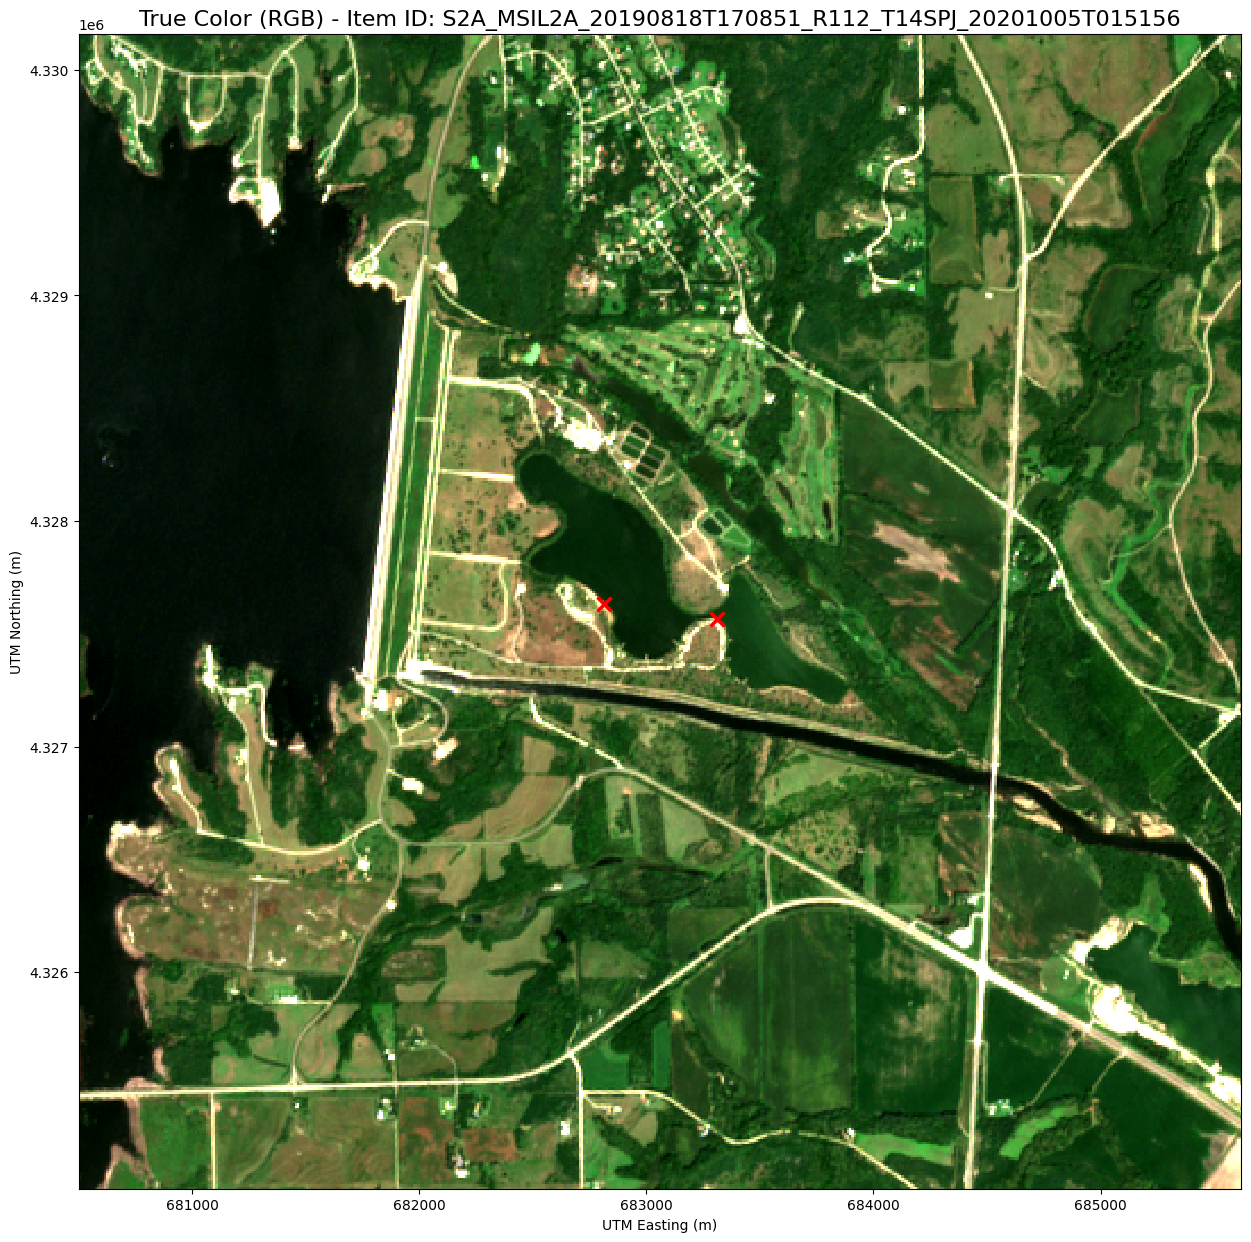

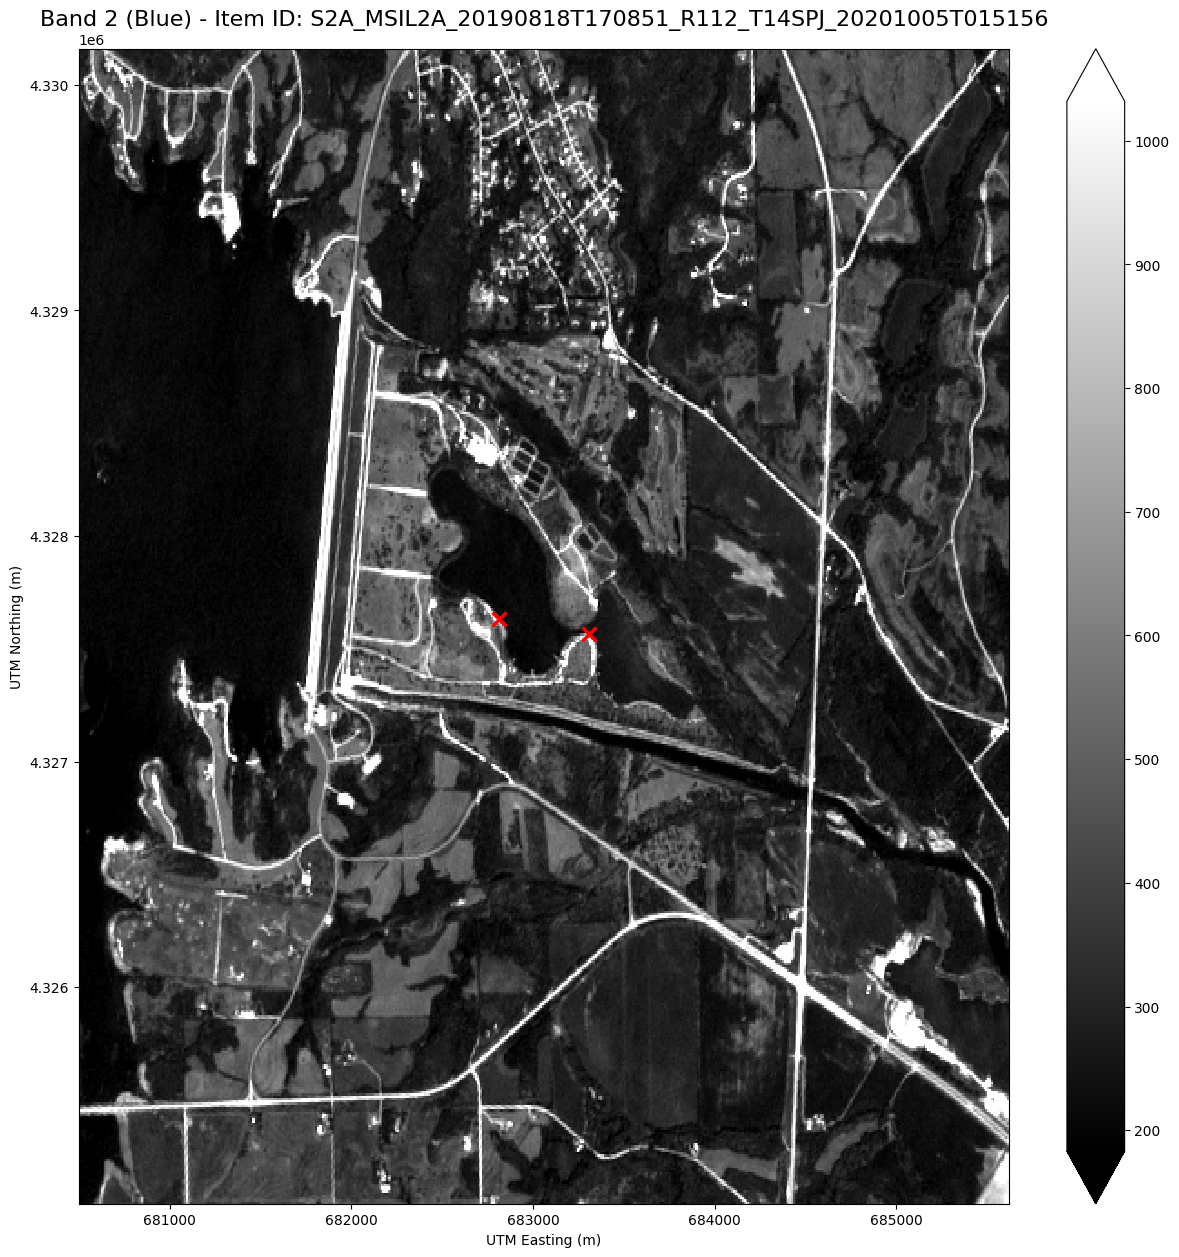

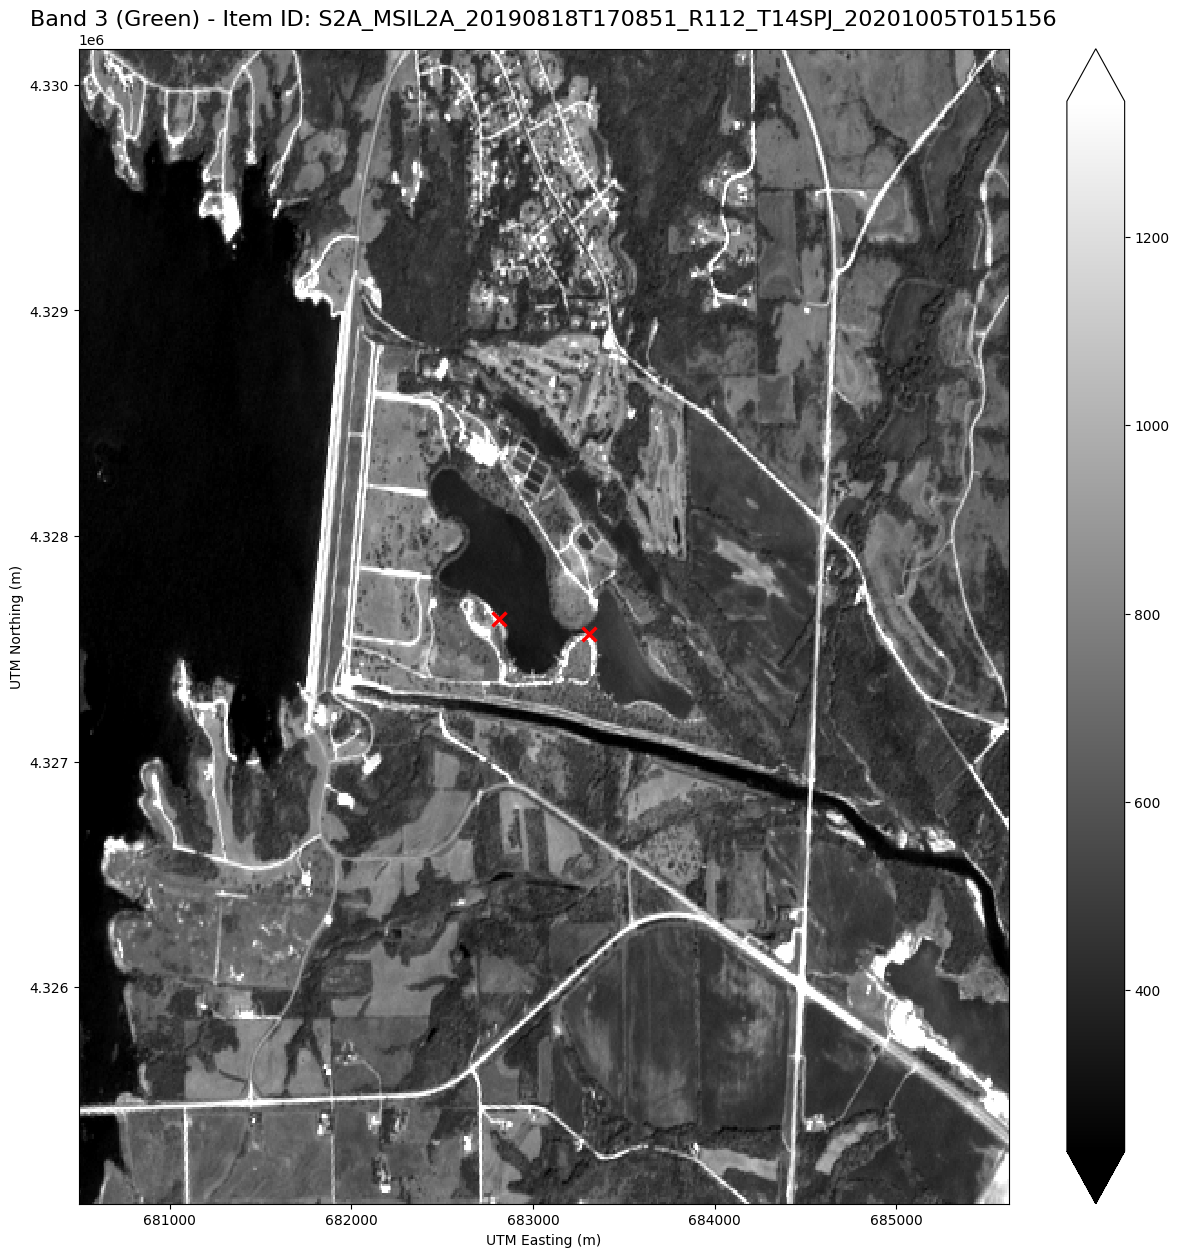

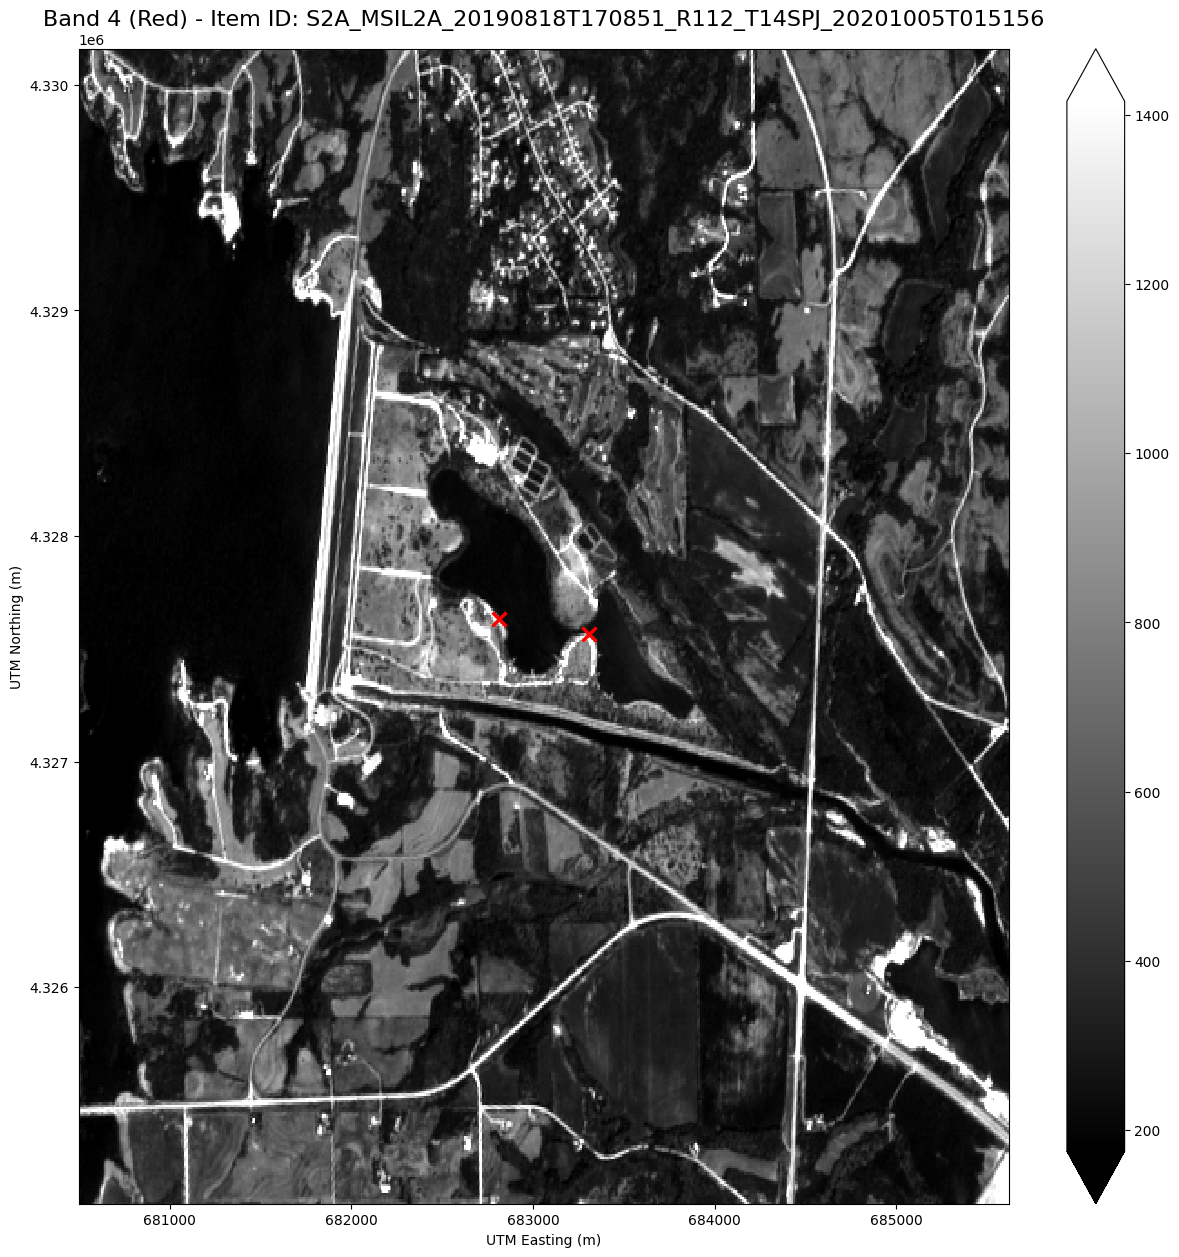

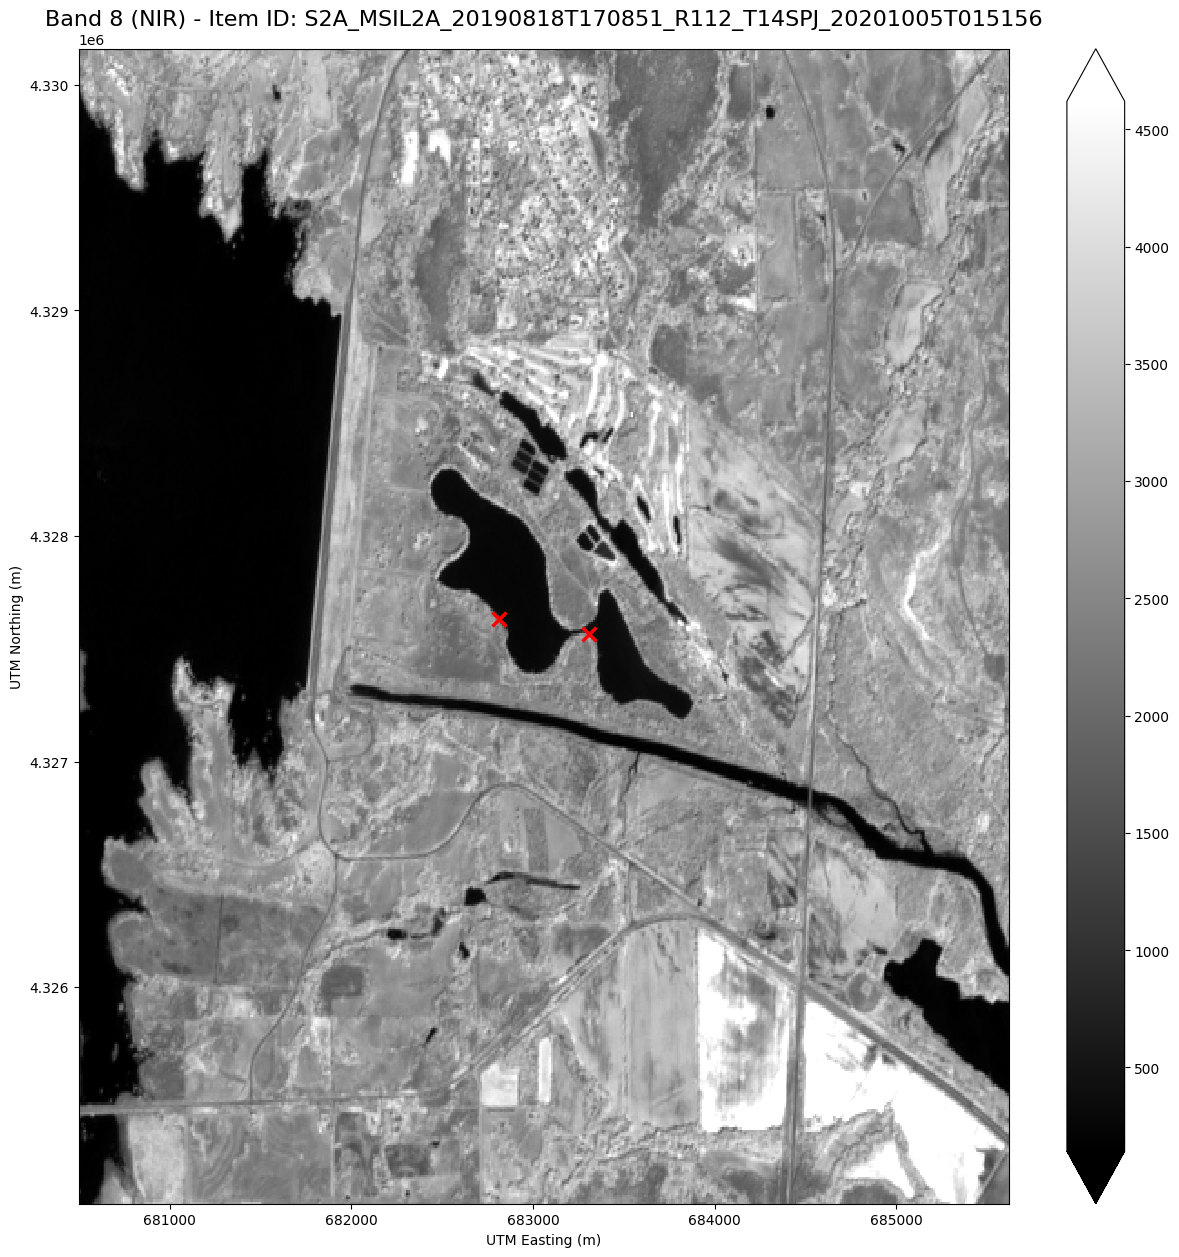

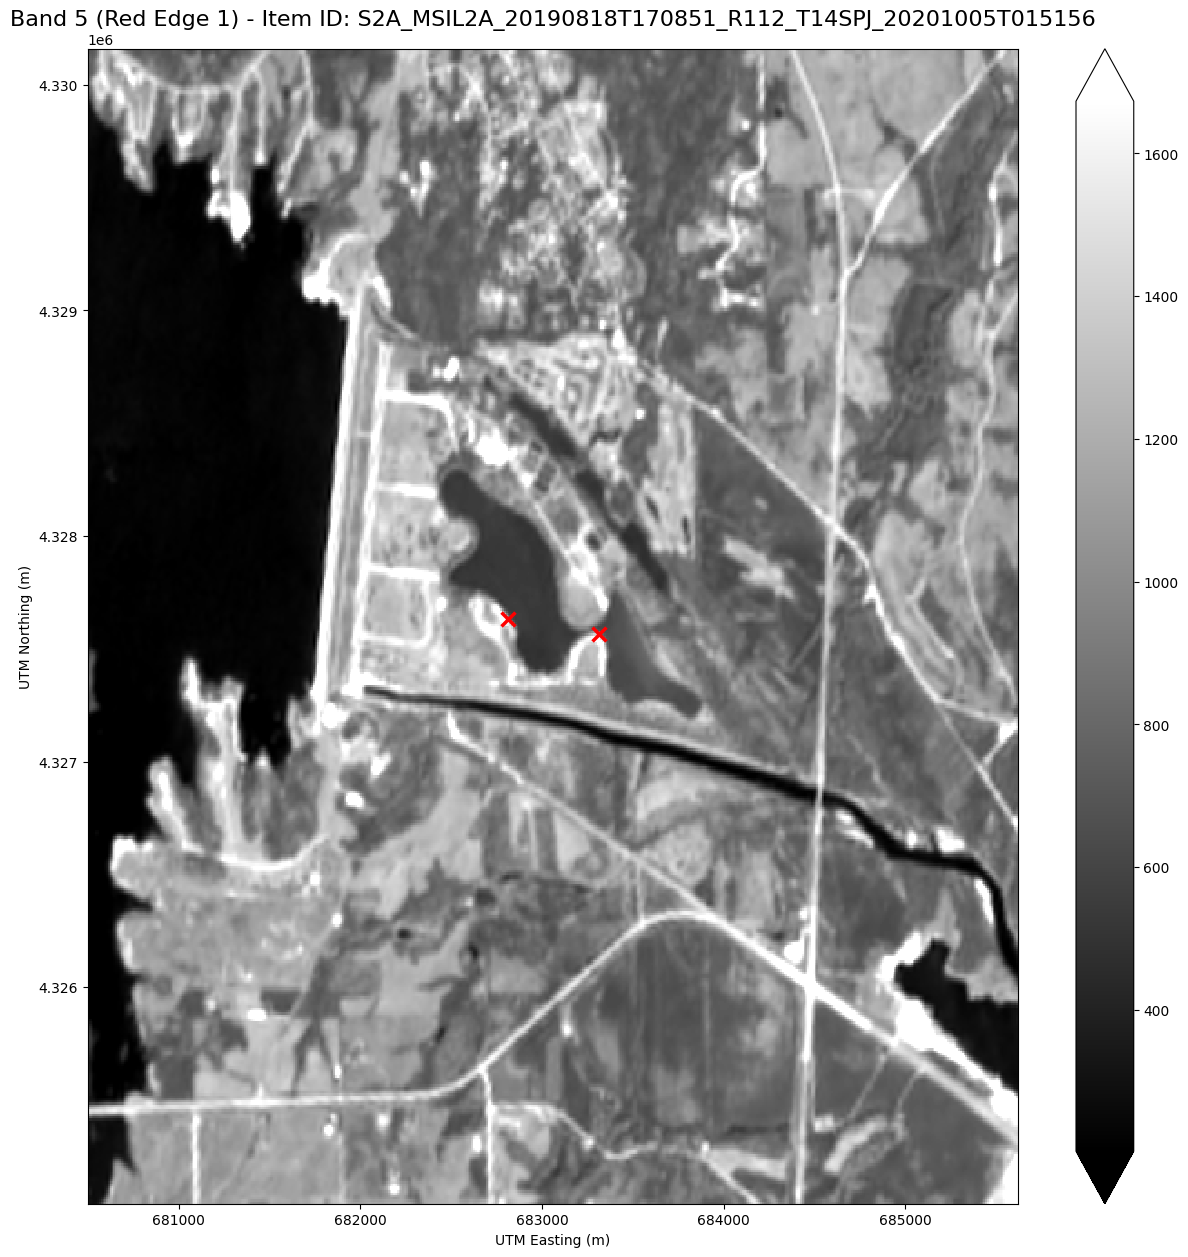

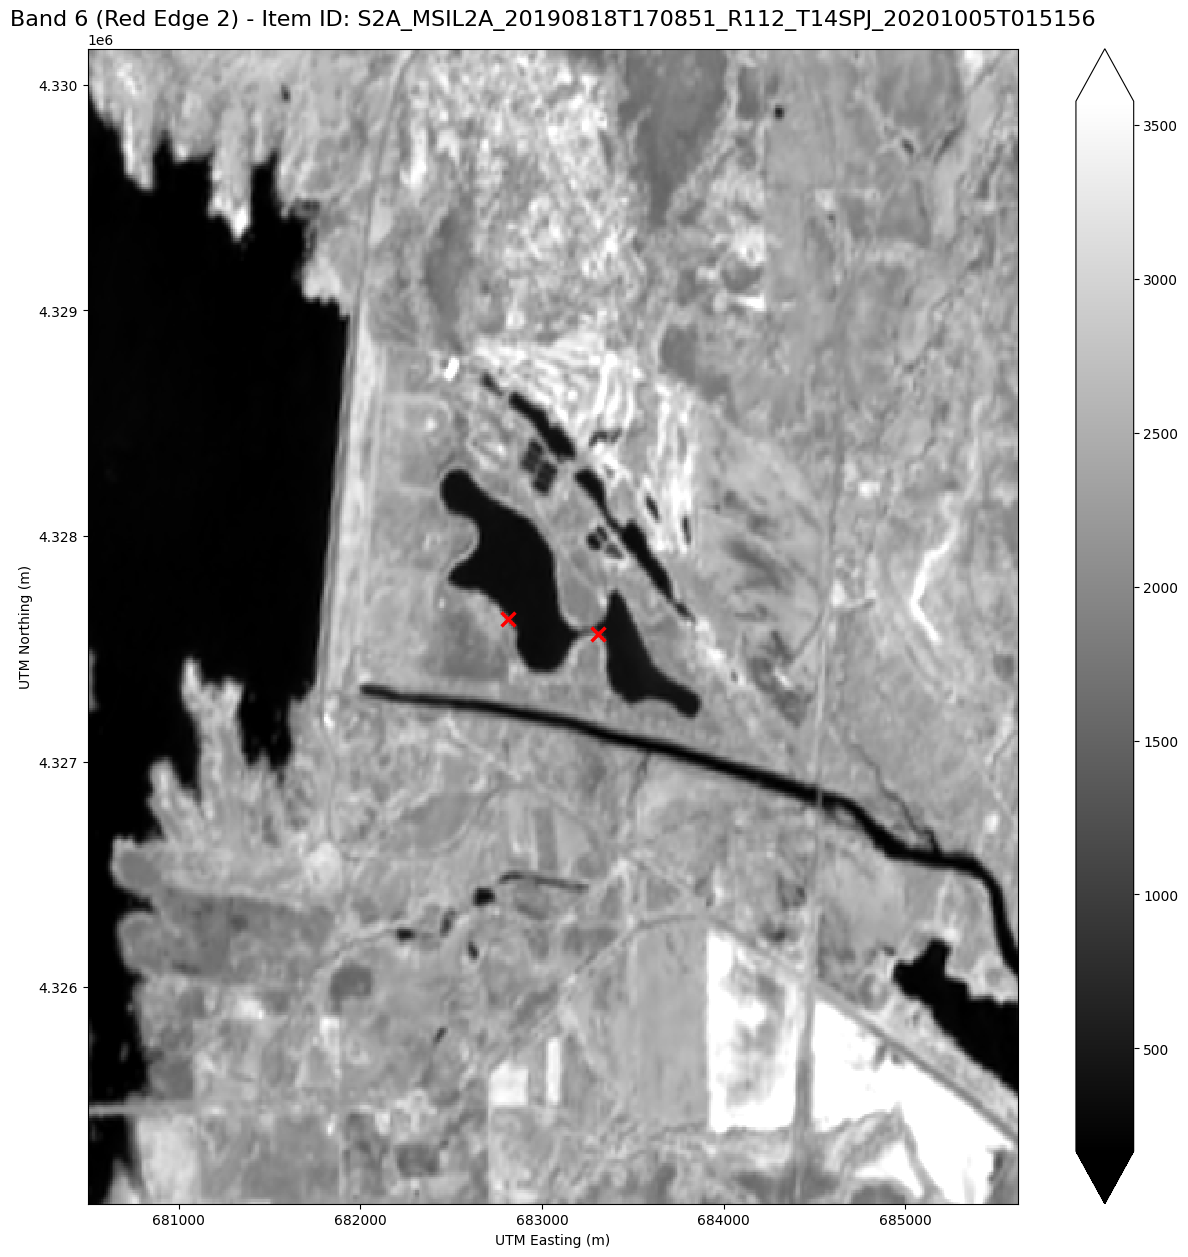

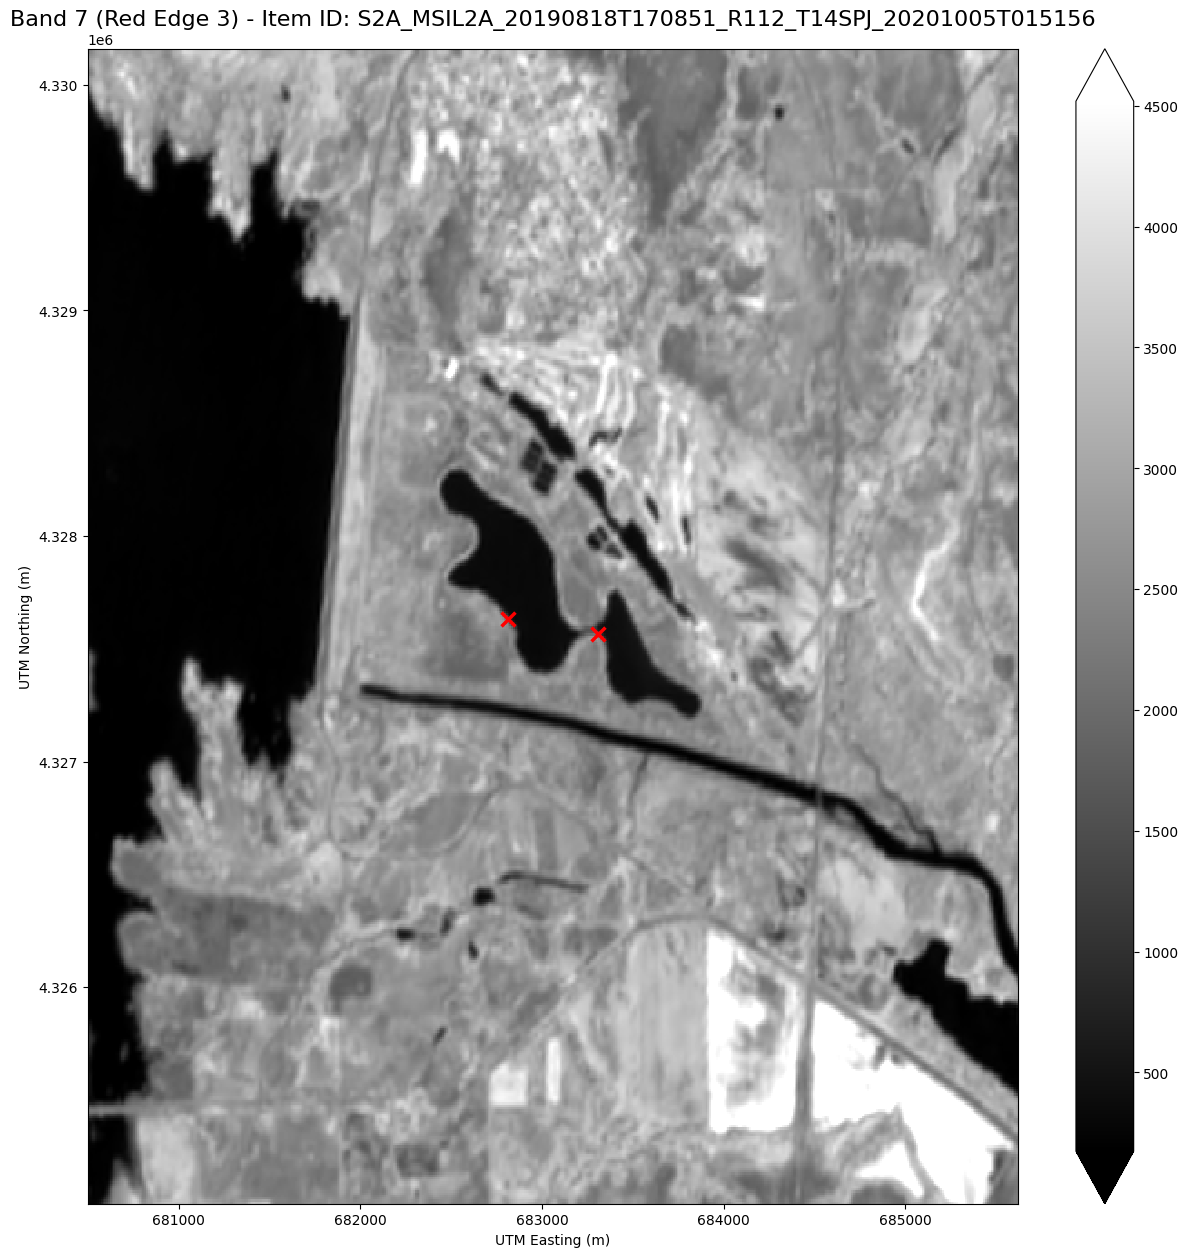

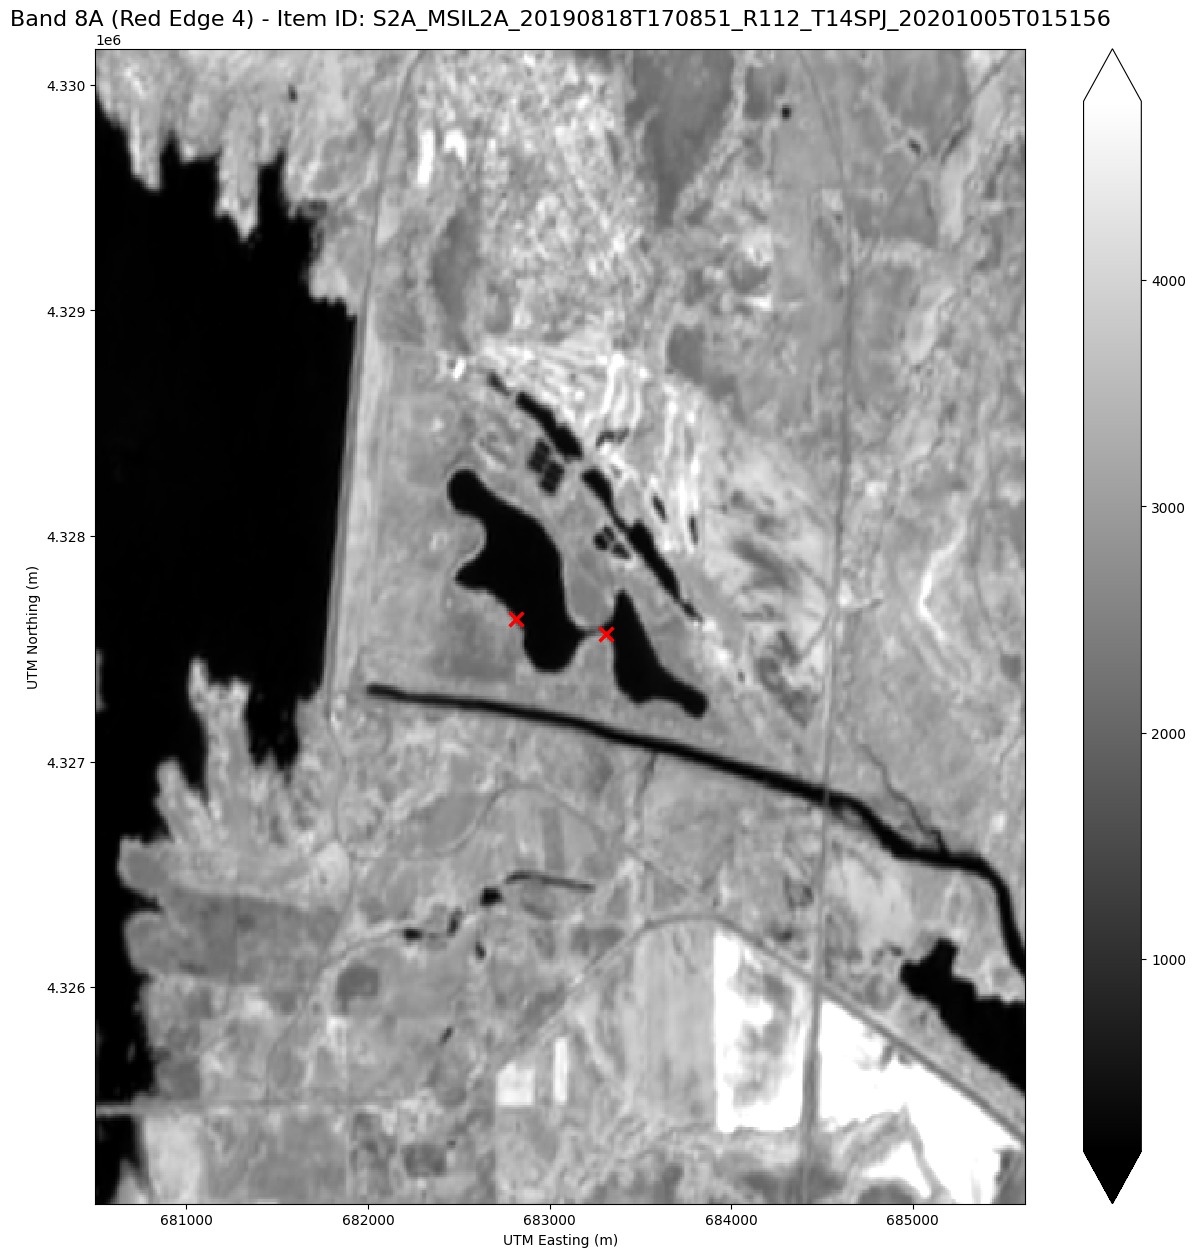

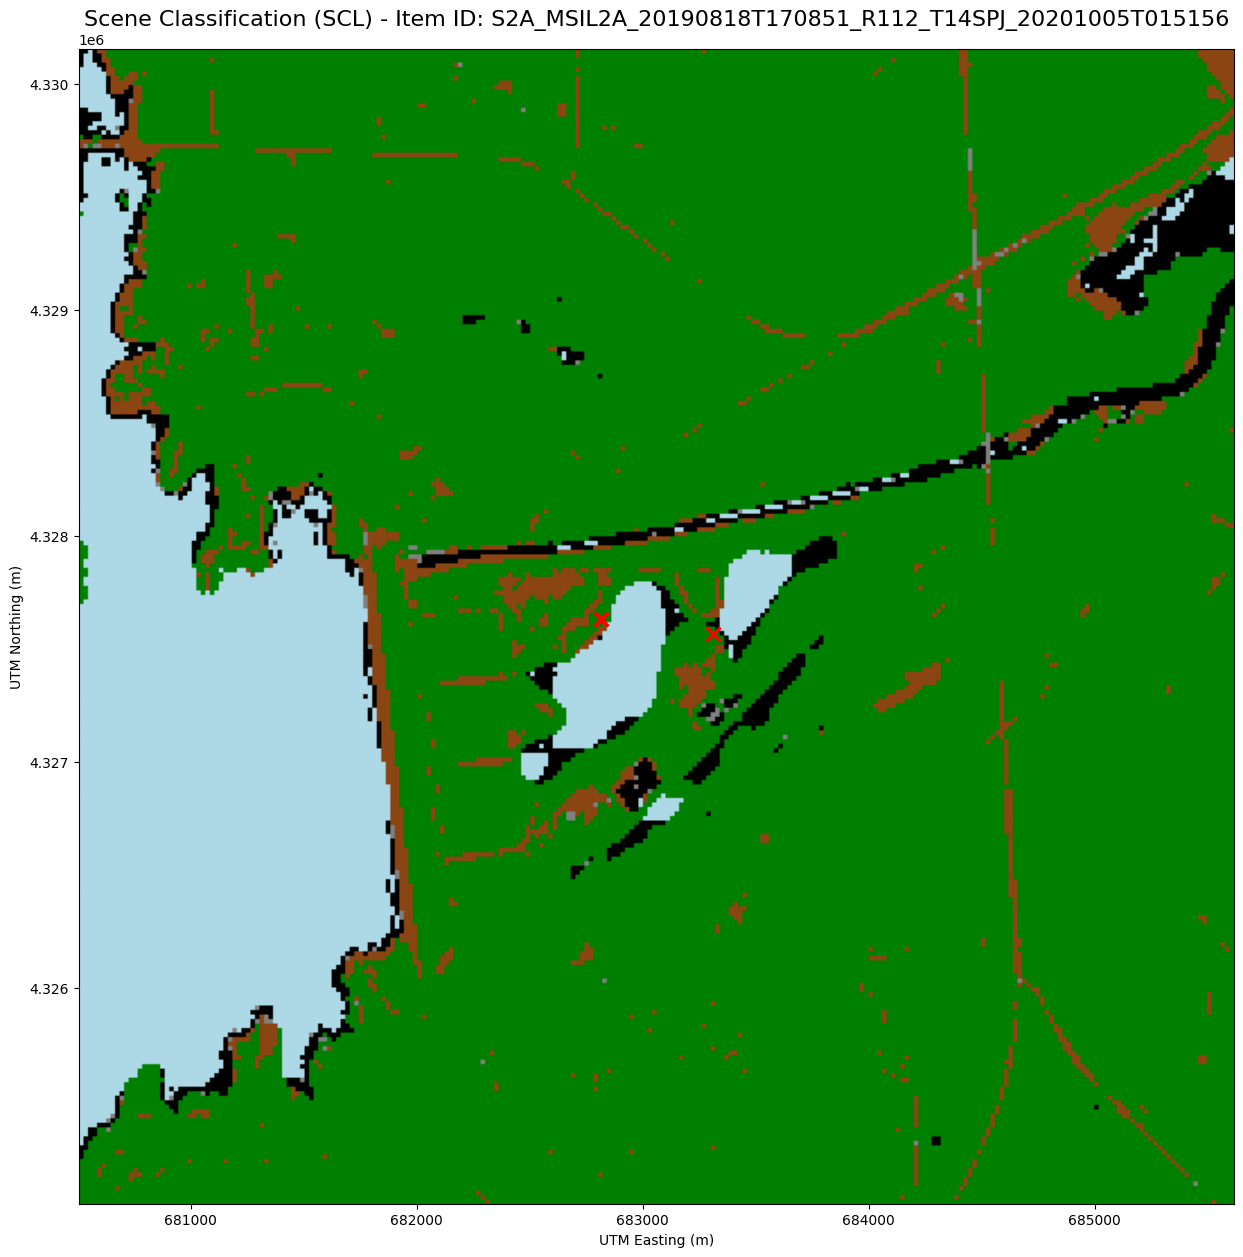

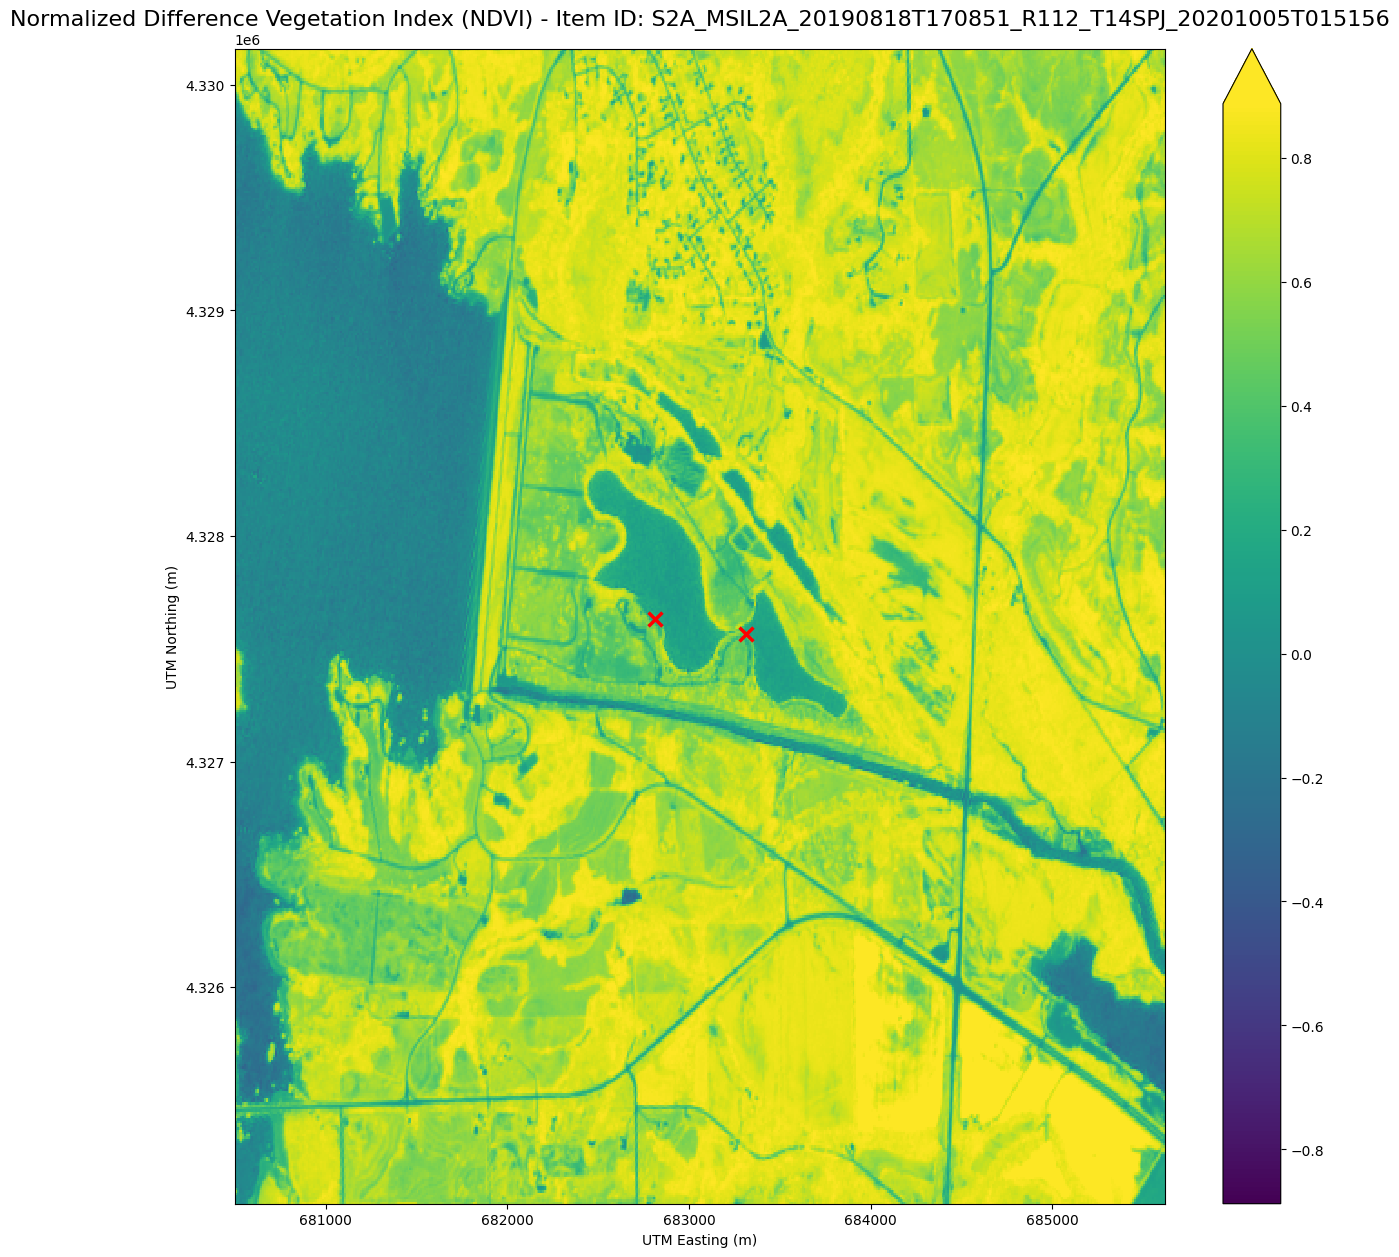

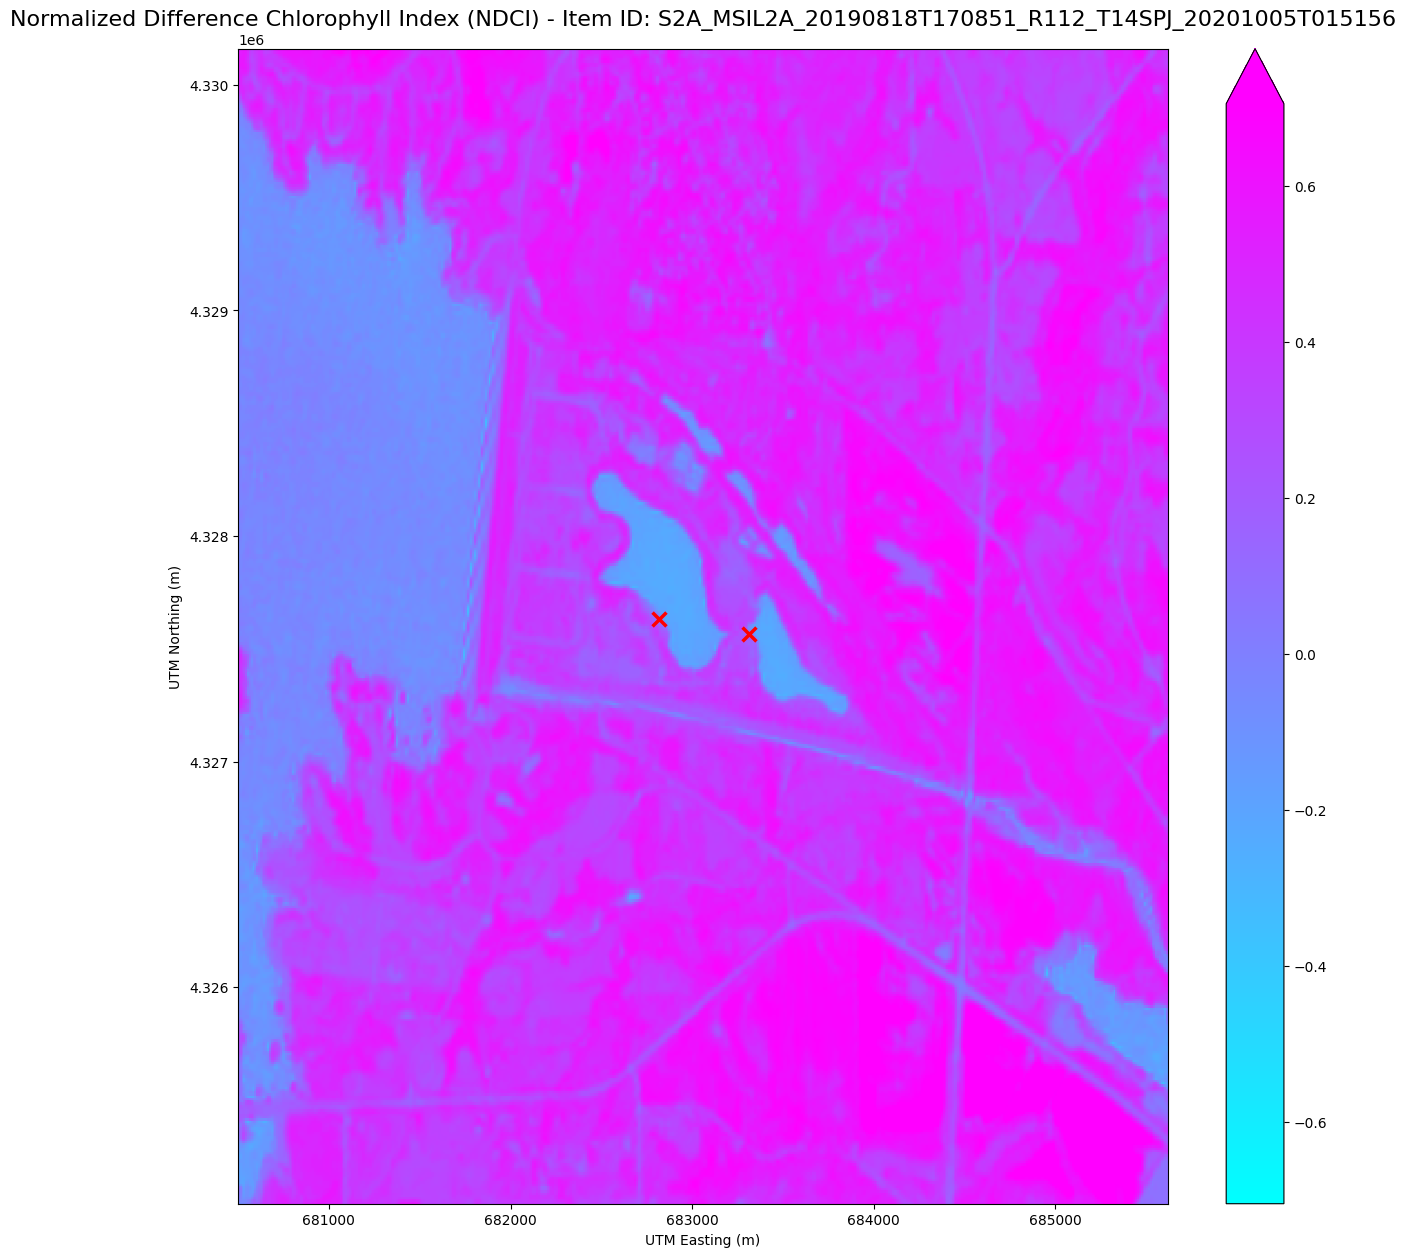


--- Individual image plots complete. ---


In [29]:
extract_and_save_tile(item, test_dates[['lat', 'lon']].copy(), initial_pixel_size=512, save_data = False, output_path = "")

In [ ]:
# Example Usage (replace with your actual data)
# Assume 'test_dates' is the DataFrame with 'lat' and 'lon' from your previous code.

# # Example of points_df creation (for demonstration)
# points_df_example = test_dates[['lat', 'lon']].copy()
# output_folder = Path(r"C:\Users\KostasPikounis\Desktop\HAB_Tiles\Tile_449_20180521") # Customize this path
#
# extract_and_save_tile(
#     item=item,
#     points_df=points_df_example,
#     initial_pixel_size=200, # 200 pixels -> 2km side at 10m resolution
#     save_data=True,
#     output_path=output_folder
# )

In [41]:
points_df = test_dates[['lat', 'lon']].copy()
initial_pixel_size=512
save_data = False
output_path = ""

In [42]:
    # --- 1. Setup and Bounding Box Calculation (Same as before) ---
    print("--- Starting Tile Extraction and Processing ---")
    
    target_crs = CRS.from_string(item.properties["proj:code"])
    center_lat = points_df['lat'].mean()
    center_lon = points_df['lon'].mean()
    print(f"Center Point (Lat/Lon): ({center_lat:.4f}, {center_lon:.4f})")
    
    initial_side_meters = initial_pixel_size * 10
    
    points_gdf = gpd.GeoDataFrame(
        points_df, 
        geometry=gpd.points_from_xy(points_df.lon, points_df.lat), 
        crs=CRS.from_string("EPSG:4326")
    )
    points_gdf = points_gdf.to_crs(target_crs)
    minx_points, miny_points, maxx_points, maxy_points = points_gdf.total_bounds
    
    center_x = (minx_points + maxx_points) / 2
    center_y = (miny_points + maxy_points) / 2
    
    required_width_meters = maxx_points - minx_points
    required_height_meters = maxy_points - miny_points
    required_margin_meters = max(required_width_meters, required_height_meters) / 2
    
    final_margin_meters = max(initial_side_meters / 2, required_margin_meters)
    
    min_x_final = center_x - final_margin_meters
    max_x_final = center_x + final_margin_meters
    min_y_final = center_y - final_margin_meters
    max_y_final = center_y + final_margin_meters
    
    final_pixel_side = int((max_x_final - min_x_final) / 10)
    print(f"Final Tile Dimension (10m pixels): {final_pixel_side} x {final_pixel_side}")
    
    clip_bbox_utm = (min_x_final, min_y_final, max_x_final, max_y_final)
    transformer_latlon_to_utm = Transformer.from_crs(CRS.from_string("EPSG:4326"), target_crs, always_xy=True)
    
    # --- 2. Asset Clipping and Processing ---
    
    # List of bands to load and their native GSD
    band_gsd_map = {
        "B02": 10, "B03": 10, "B04": 10, "B08": 10, "visual": 10,
        "B05": 20, "B06": 20, "B07": 20, "B8A": 20, "SCL": 20
    }
    
    clipped_data = {}
    
    for asset_key, gsd in band_gsd_map.items():
        asset_href = pc.sign(item.assets[asset_key].href)
        ds = rioxarray.open_rasterio(asset_href)
        
        ds_clip = ds.rio.clip_box(
            minx=clip_bbox_utm[0], 
            miny=clip_bbox_utm[1], 
            maxx=clip_bbox_utm[2], 
            maxy=clip_bbox_utm[3],
            crs=target_crs
        )
        
        # Resample 20m bands to 10m to ensure consistent output size
        if gsd == 20:
            resampling_method = rasterio.enums.Resampling.nearest if asset_key == "SCL" else rasterio.enums.Resampling.bilinear

            ds_clip = ds_clip.rio.reproject(
                ds_clip.rio.crs, 
                resolution=10, 
                resampling=resampling_method
            )

        # Ensure the final shape matches the calculated pixel size
        # We index the image space (y, x) to ensure we get the exact square size.
        ds_clip = ds_clip.isel(
            y=slice(0, final_pixel_side),
            x=slice(0, final_pixel_side)
        )
        
        clipped_data[asset_key] = ds_clip
        print(f"Clipped {asset_key}: Shape {ds_clip.shape}")

    # --- 3. Calculate Spectral Indices (NDVI and NDCI) ---
    
    # Get relevant DataArrays (squeeze() removes the single band dimension)
    b04 = clipped_data["B04"].squeeze()
    b05 = clipped_data["B05"].squeeze()
    b07 = clipped_data["B07"].squeeze()
    b08 = clipped_data["B08"].squeeze()

    # Calculate NDVI: (B08 - B04) / (B08 + B04)
    # Use xarray's `.where()` to mask out areas where the divisor is zero to prevent warnings
    ndvi = (b08 - b04) / (b08 + b04).where((b08 + b04) != 0, 0)
    
    # Calculate NDCI: (B07 - B05) / (B07 + B05)
    ndci = (b07 - b05) / (b07 + b05).where((b07 + b05) != 0, 0)
    
    # Add indices back to the data dictionary as new DataArrays
    clipped_data["NDVI"] = ndvi
    clipped_data["NDCI"] = ndci
    print(f"Calculated NDVI: Shape {ndvi.shape}")
    print(f"Calculated NDCI: Shape {ndci.shape}")
  

--- Starting Tile Extraction and Processing ---
Center Point (Lat/Lon): (39.0783, -96.8837)
Final Tile Dimension (10m pixels): 512 x 512
Clipped B02: Shape (1, 512, 512)
Clipped B03: Shape (1, 512, 512)
Clipped B04: Shape (1, 512, 512)
Clipped B08: Shape (1, 512, 512)
Clipped visual: Shape (3, 512, 512)
Clipped B05: Shape (1, 512, 512)
Clipped B06: Shape (1, 512, 512)
Clipped B07: Shape (1, 512, 512)
Clipped B8A: Shape (1, 512, 512)
Clipped SCL: Shape (1, 512, 512)
Calculated NDVI: Shape (512, 512)
Calculated NDCI: Shape (512, 512)


In [45]:
print(b04)

<xarray.DataArray (y: 512, x: 512)> Size: 524kB
[262144 values with dtype=uint16]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 4kB 6.805e+05 6.805e+05 ... 6.856e+05 6.856e+05
  * y            (y) float64 4kB 4.33e+06 4.33e+06 ... 4.325e+06 4.325e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0


In [53]:
b08.values.max()

np.uint16(6768)

In [57]:
b04.values.max()

np.uint16(5224)

In [66]:
for k, v in clipped_data.items():
    print (k, v.values.max())

B02 4696
B03 4664
B04 5224
B08 6768
visual 255
B05 4014
B06 5296
B07 6631
B8A 6905
SCL 9
NDVI 282.33620689655174
NDCI 242.63703703703703
